# Quantum Harmonic Oscillator in a Mismatched Hermite Basis

The physical harmonic oscillator has angular frequency $\omega$. We represent its Hamiltonian in a truncated Hermite basis generated by a possibly different reference frequency $\Omega$.

The finite basis is

$$
\mathcal H_{N_b}
=
\operatorname{span}
\left\{
\lvert0;\Omega\rangle,
\ldots,
\lvert N_b-1;\Omega\rangle
\right\}.
$$

The matrix being diagonalized is the projected physical Hamiltonian

$$
\boxed{
\mathbf H_{N_b}
=
P_{N_b}\hat H(\omega)P_{N_b}
},
$$

with matrix elements

$$
H_{mn}
=
\langle m;\Omega\vert
\hat H(\omega)
\vert n;\Omega\rangle.
$$

When $\Omega=\omega$, the chosen basis is the exact eigenbasis and the matrix is diagonal. When $\Omega\neq\omega$, the matrix is not diagonal and its eigenvectors recover the physical states as superpositions of reference-basis states.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import (
    LinearSegmentedColormap,
    TwoSlopeNorm,
)
from numpy.typing import NDArray
from scipy.linalg import eigh

## 1. Physical Parameters and Basis Parameters

The physical Hamiltonian is

$$
\hat H(\omega)
=
\frac{\hat p^2}{2m}
+
\frac12m\omega^2\hat x^2.
$$

The reference basis is controlled independently by $\Omega$. Its natural length scale is

$$
\ell_\Omega
=
\sqrt{
\frac{\hbar}{m\Omega}
}.
$$

The numerical approximation is controlled by:

- the basis dimension $N_b$;
- the reference frequency $\Omega$.

No finite spatial boundary is introduced.

In [2]:
hbar = 1.0
mass = 1.0

physical_frequency = 1.0
reference_frequency = 0.60

basis_size = 24

reference_length = np.sqrt(
    hbar
    / (
        mass
        * reference_frequency
    )
)

print(
    f"Physical frequency ω = "
    f"{physical_frequency:.3f}"
)

print(
    f"Reference frequency Ω = "
    f"{reference_frequency:.3f}"
)

print(
    f"Reference length ℓΩ = "
    f"{reference_length:.3f}"
)

print(
    f"Basis dimension Nb = "
    f"{basis_size}"
)

Physical frequency ω = 1.000
Reference frequency Ω = 0.600
Reference length ℓΩ = 1.291
Basis dimension Nb = 24


## 2. Ladder-Operator Matrices

The annihilation and creation operators satisfy

$$
\hat a\lvert n\rangle
=
\sqrt n\lvert n-1\rangle,
$$

$$
\hat a^\dagger\lvert n\rangle
=
\sqrt{n+1}\lvert n+1\rangle.
$$

Their finite matrix representations are sparse and connect neighboring basis states.

In [3]:
def build_ladder_operators(
    size: int,
) -> tuple[
    NDArray[np.complex128],
    NDArray[np.complex128],
]:
    coefficients = np.sqrt(
        np.arange(
            1,
            size,
            dtype=np.float64,
        )
    )

    annihilation = np.diag(
        coefficients,
        k=1,
    ).astype(np.complex128)

    creation = (
        annihilation.conjugate().T
    )

    return annihilation, creation


annihilation, creation = (
    build_ladder_operators(
        size=basis_size,
    )
)

number_operator = (
    creation @ annihilation
)

identity = np.eye(
    basis_size,
    dtype=np.complex128,
)

## 3. Position and Momentum Operators

Using the reference frequency $\Omega$,

$$
\hat x
=
\sqrt{
\frac{\hbar}{2m\Omega}
}
\left(
\hat a+\hat a^\dagger
\right),
$$

$$
\hat p
=
i
\sqrt{
\frac{m\hbar\Omega}{2}
}
\left(
\hat a^\dagger-\hat a
\right).
$$

In [4]:
position = (
    np.sqrt(
        hbar
        / (
            2.0
            * mass
            * reference_frequency
        )
    )
    * (
        annihilation
        + creation
    )
)

momentum = (
    1.0j
    * np.sqrt(
        mass
        * hbar
        * reference_frequency
        / 2.0
    )
    * (
        creation
        - annihilation
    )
)

assert np.allclose(
    position,
    position.conjugate().T,
)

assert np.allclose(
    momentum,
    momentum.conjugate().T,
)

print("Position and momentum matrices are Hermitian.")

Position and momentum matrices are Hermitian.


## 4. Projected Physical Hamiltonian

The physical Hamiltonian projected onto the reference basis is

$$
\hat H
=
\frac{\hbar}{4\Omega}
\left[
(\Omega^2+\omega^2)
(2\hat N+\hat I)
+
(\omega^2-\Omega^2)
\left(
\hat a^2+\hat a^{\dagger2}
\right)
\right].
$$

The first term is diagonal. The second term couples states whose quantum numbers differ by two:

$$
\Delta n=\pm2.
$$

This preserves parity: even basis states mix only with even states, and odd basis states mix only with odd states.

In [5]:
def build_projected_qho_hamiltonian(
    size: int,
    physical_frequency: float,
    reference_frequency: float,
    mass: float = 1.0,
    hbar: float = 1.0,
) -> NDArray[np.complex128]:
    annihilation, creation = (
        build_ladder_operators(
            size=size,
        )
    )

    number_operator = (
        creation @ annihilation
    )

    identity = np.eye(
        size,
        dtype=np.complex128,
    )

    diagonal_part = (
        (
            reference_frequency**2
            + physical_frequency**2
        )
        * (
            2.0 * number_operator
            + identity
        )
    )

    coupling_part = (
        (
            physical_frequency**2
            - reference_frequency**2
        )
        * (
            annihilation @ annihilation
            + creation @ creation
        )
    )

    return (
        hbar
        / (
            4.0
            * reference_frequency
        )
        * (
            diagonal_part
            + coupling_part
        )
    )


hamiltonian = (
    build_projected_qho_hamiltonian(
        size=basis_size,
        physical_frequency=(
            physical_frequency
        ),
        reference_frequency=(
            reference_frequency
        ),
        mass=mass,
        hbar=hbar,
    )
)

assert np.allclose(
    hamiltonian,
    hamiltonian.conjugate().T,
)

print("Projected Hamiltonian is Hermitian.")

Projected Hamiltonian is Hermitian.


## 5. Hamiltonian Matrix Structure

For $\Omega\neq\omega$, the second off-diagonals are populated. The signed heat map shows the matrix elements:

- red: negative;
- white: zero;
- blue: positive.

The color normalization is symmetric about zero.

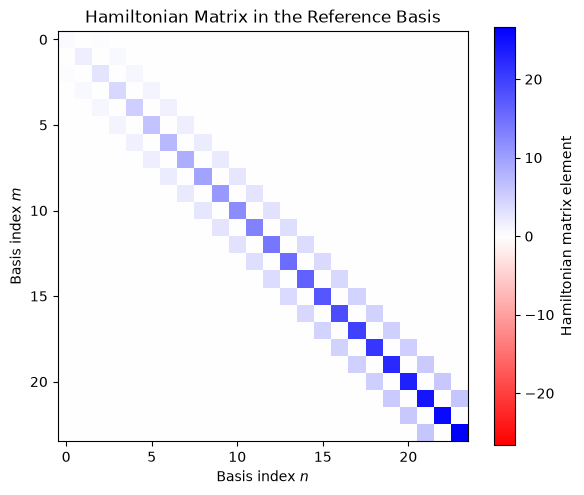

In [6]:
hamiltonian_real = np.real_if_close(
    hamiltonian
).real

maximum_magnitude = np.max(
    np.abs(hamiltonian_real)
)

normalization = TwoSlopeNorm(
    vmin=-maximum_magnitude,
    vcenter=0.0,
    vmax=maximum_magnitude,
)

red_white_blue = (
    LinearSegmentedColormap.from_list(
        "red_white_blue",
        [
            "red",
            "white",
            "blue",
        ],
    )
)

fig, ax = plt.subplots(
    figsize=(6, 5)
)

image = ax.imshow(
    hamiltonian_real,
    cmap=red_white_blue,
    norm=normalization,
    interpolation="nearest",
)

ax.set_xlabel("Basis index $n$")
ax.set_ylabel("Basis index $m$")
ax.set_title(
    "Hamiltonian Matrix in the Reference Basis"
)

colorbar = fig.colorbar(
    image,
    ax=ax,
)

colorbar.set_label(
    "Hamiltonian matrix element"
)

fig.tight_layout()
plt.show()

## 6. Diagonalization

Solve the finite-dimensional eigenproblem

$$
\mathbf H_{N_b}\mathbf c_j
=
E_j^{(N_b)}\mathbf c_j.
$$

The coefficient vector $\mathbf c_j$ represents

$$
\lvert\psi_j\rangle
=
\sum_{n=0}^{N_b-1}
c_n^{(j)}
\lvert n;\Omega\rangle.
$$

The exact QHO energies are

$$
E_j
=
\hbar\omega
\left(
j+\frac12
\right).
$$

In [7]:
energies, eigenvectors = eigh(
    hamiltonian
)

number_of_states = 8

quantum_numbers = np.arange(
    number_of_states,
    dtype=np.float64,
)

exact_energies = (
    hbar
    * physical_frequency
    * (
        quantum_numbers
        + 0.5
    )
)

print(
    " n      numerical         exact          error"
)
print(
    "------------------------------------------------"
)

for n in range(number_of_states):
    error = (
        energies[n]
        - exact_energies[n]
    )

    print(
        f"{n:2d}  "
        f"{energies[n]:14.10f}  "
        f"{exact_energies[n]:14.10f}  "
        f"{error:12.3e}"
    )

 n      numerical         exact          error
------------------------------------------------
 0    0.5000000000    0.5000000000     1.321e-14
 1    1.5000000000    1.5000000000     3.126e-13
 2    2.5000000000    2.5000000000     4.827e-11
 3    3.5000000004    3.5000000000     3.699e-10
 4    4.5000000236    4.5000000000     2.362e-08
 5    5.5000001068    5.5000000000     1.068e-07
 6    6.5000036123    6.5000000000     3.612e-06
 7    7.5000114225    7.5000000000     1.142e-05


## 7. Basis-State Composition

When $\Omega\neq\omega$, a physical eigenstate is a superposition of reference-basis states. Parity implies:

- the physical ground state contains only even reference states;
- the first excited state contains only odd reference states.

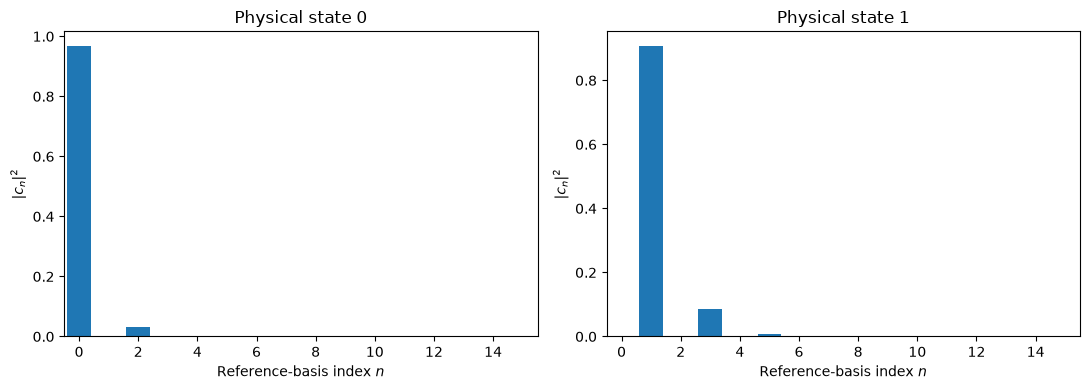

In [8]:
fig, axes = plt.subplots(
    ncols=2,
    figsize=(11, 4),
)

for state_index, ax in enumerate(axes):
    weights = np.abs(
        eigenvectors[
            :,
            state_index,
        ]
    )**2

    ax.bar(
        np.arange(basis_size),
        weights,
        color="tab:blue",
    )

    ax.set_xlabel(
        "Reference-basis index $n$"
    )

    ax.set_ylabel(
        r"$|c_n|^2$"
    )

    ax.set_title(
        f"Physical state {state_index}"
    )

    ax.set_xlim(
        -0.5,
        min(
            basis_size - 0.5,
            15.5,
        ),
    )

fig.tight_layout()
plt.show()

## 8. Hermite Functions in Position Space

The normalized reference-basis functions are

$$
\phi_n^{(\Omega)}(x)
=
\langle x\vert n;\Omega\rangle.
$$

They can be generated stably using the recurrence

$$
\phi_{n+1}
=
\sqrt{
\frac{2}{n+1}
}
\frac{x}{\ell_\Omega}
\phi_n
-
\sqrt{
\frac{n}{n+1}
}
\phi_{n-1}.
$$

Every basis function is square-integrable and decays at infinity.

In [9]:
def evaluate_hermite_basis(
    coordinates: NDArray[np.float64],
    size: int,
    mass: float,
    angular_frequency: float,
    hbar: float,
) -> NDArray[np.float64]:
    length_scale = np.sqrt(
        hbar
        / (
            mass
            * angular_frequency
        )
    )

    dimensionless_coordinate = (
        coordinates / length_scale
    )

    basis_values = np.zeros(
        (
            coordinates.size,
            size,
        ),
        dtype=np.float64,
    )

    basis_values[:, 0] = (
        np.pi**(-0.25)
        / np.sqrt(length_scale)
        * np.exp(
            -0.5
            * dimensionless_coordinate**2
        )
    )

    if size == 1:
        return basis_values

    basis_values[:, 1] = (
        np.sqrt(2.0)
        * dimensionless_coordinate
        * basis_values[:, 0]
    )

    for n in range(1, size - 1):
        basis_values[:, n + 1] = (
            np.sqrt(
                2.0 / (n + 1)
            )
            * dimensionless_coordinate
            * basis_values[:, n]
            - np.sqrt(
                n / (n + 1)
            )
            * basis_values[:, n - 1]
        )

    return basis_values

## 9. Reconstruct the Physical Wavefunctions

The position-space eigenfunction is reconstructed from the numerical coefficient vector:

$$
\psi_j(x)
=
\sum_{n=0}^{N_b-1}
c_n^{(j)}
\phi_n^{(\Omega)}(x).
$$

The comparison below uses probability densities so that the arbitrary eigenvector phase does not affect the result.

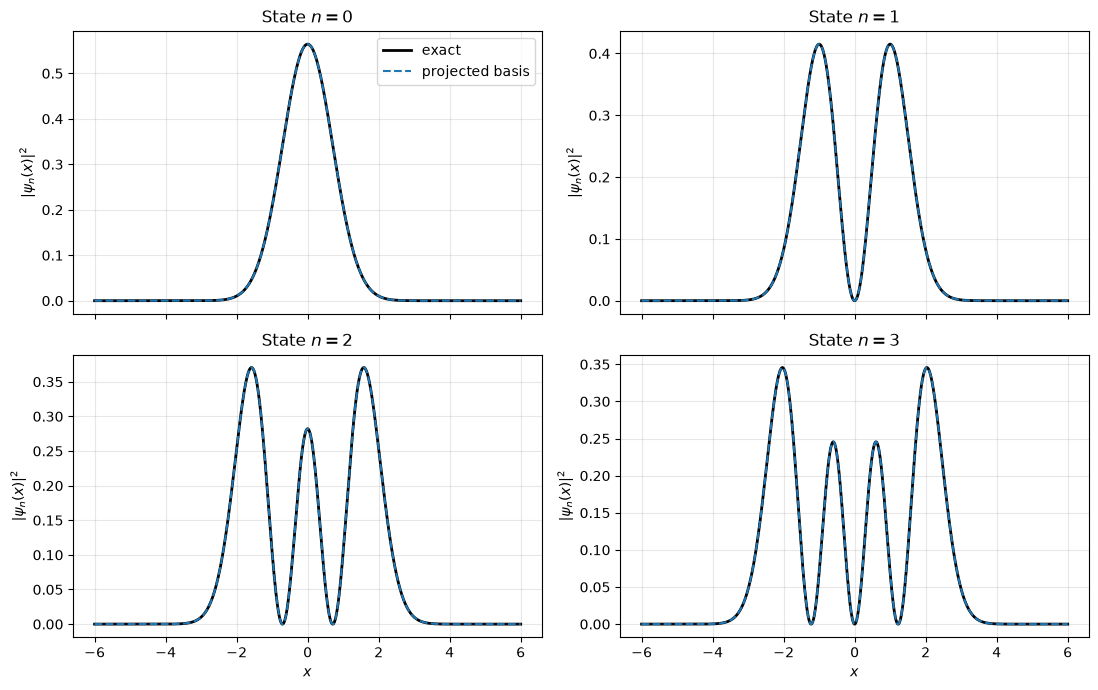

In [10]:
physical_length = np.sqrt(
    hbar
    / (
        mass
        * physical_frequency
    )
)

coordinates = np.linspace(
    -6.0 * physical_length,
    6.0 * physical_length,
    1200,
    dtype=np.float64,
)

reference_basis_values = (
    evaluate_hermite_basis(
        coordinates=coordinates,
        size=basis_size,
        mass=mass,
        angular_frequency=(
            reference_frequency
        ),
        hbar=hbar,
    )
)

physical_basis_values = (
    evaluate_hermite_basis(
        coordinates=coordinates,
        size=4,
        mass=mass,
        angular_frequency=(
            physical_frequency
        ),
        hbar=hbar,
    )
)

reconstructed_states = (
    reference_basis_values
    @ eigenvectors[:, :4]
)

fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(11, 7),
    sharex=True,
)

for state_index, ax in enumerate(
    axes.flat
):
    numerical_density = np.abs(
        reconstructed_states[
            :,
            state_index,
        ]
    )**2

    exact_density = (
        physical_basis_values[
            :,
            state_index,
        ]**2
    )

    ax.plot(
        coordinates,
        exact_density,
        color="black",
        linewidth=2.0,
        label="exact",
    )

    ax.plot(
        coordinates,
        numerical_density,
        linestyle="--",
        color="tab:blue",
        label="projected basis",
    )

    ax.set_title(
        f"State $n={state_index}$"
    )

    ax.set_ylabel(
        r"$|\psi_n(x)|^2$"
    )

    ax.grid(alpha=0.3)

axes[-1, 0].set_xlabel("$x$")
axes[-1, 1].set_xlabel("$x$")
axes[0, 0].legend()

fig.tight_layout()
plt.show()

## 10. Basis-Size Convergence

For a mismatched reference frequency, the projected eigenvalues converge as

$$
N_b\rightarrow\infty.
$$

Low-energy states converge first because they require fewer reference-basis components.

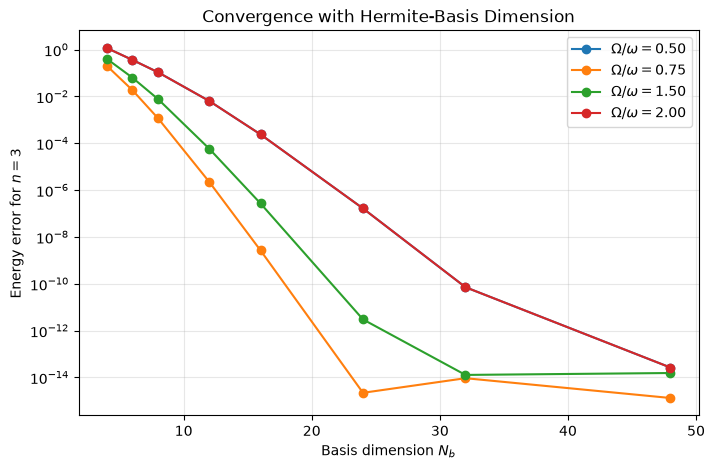

In [11]:
basis_sizes = np.array(
    [4, 6, 8, 12, 16, 24, 32, 48],
    dtype=np.int64,
)

frequency_ratios = [
    0.50,
    0.75,
    1.50,
    2.00,
]

target_state = 3

exact_target_energy = (
    hbar
    * physical_frequency
    * (
        target_state
        + 0.5
    )
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

for ratio in frequency_ratios:
    errors = []

    for size in basis_sizes:
        matrix = (
            build_projected_qho_hamiltonian(
                size=int(size),
                physical_frequency=(
                    physical_frequency
                ),
                reference_frequency=(
                    ratio
                    * physical_frequency
                ),
                mass=mass,
                hbar=hbar,
            )
        )

        eigenvalues = eigh(
            matrix,
            eigvals_only=True,
        )

        error = abs(
            eigenvalues[target_state]
            - exact_target_energy
        )

        errors.append(
            max(error, 1.0e-16)
        )

    ax.semilogy(
        basis_sizes,
        errors,
        marker="o",
        label=rf"$\Omega/\omega={ratio:.2f}$",
    )

ax.set_xlabel(
    r"Basis dimension $N_b$"
)

ax.set_ylabel(
    rf"Energy error for $n={target_state}$"
)

ax.set_title(
    "Convergence with Hermite-Basis Dimension"
)

ax.legend()
ax.grid(
    which="both",
    alpha=0.3,
)

plt.show()

## 11. Dependence on the Reference Frequency

At fixed basis size, the reference frequency controls how efficiently the truncated basis represents the physical states.

For the exact QHO, the optimal choice is

$$
\Omega=\omega,
$$

because the projected Hamiltonian is then diagonal. For an unknown or anharmonic system, $\Omega$ becomes a variational basis-scale parameter.

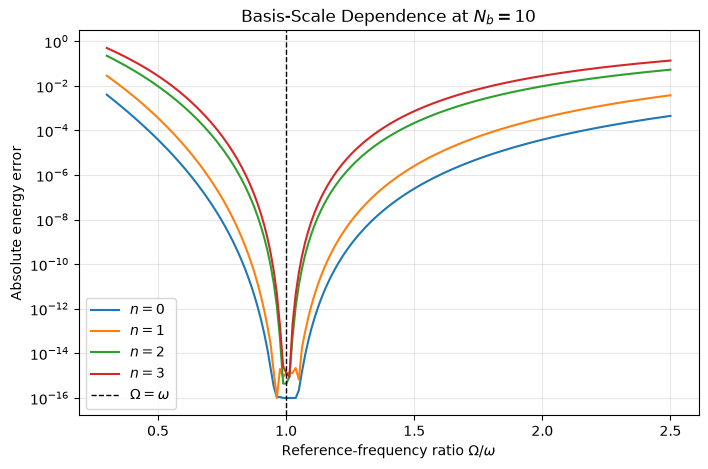

In [12]:
frequency_ratios = np.linspace(
    0.30,
    2.50,
    180,
    dtype=np.float64,
)

fixed_basis_size = 10
state_indices = [0, 1, 2, 3]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

for state_index in state_indices:
    errors = []

    exact_energy = (
        hbar
        * physical_frequency
        * (
            state_index
            + 0.5
        )
    )

    for ratio in frequency_ratios:
        matrix = (
            build_projected_qho_hamiltonian(
                size=fixed_basis_size,
                physical_frequency=(
                    physical_frequency
                ),
                reference_frequency=(
                    ratio
                    * physical_frequency
                ),
                mass=mass,
                hbar=hbar,
            )
        )

        eigenvalues = eigh(
            matrix,
            eigvals_only=True,
        )

        errors.append(
            max(
                abs(
                    eigenvalues[state_index]
                    - exact_energy
                ),
                1.0e-16,
            )
        )

    ax.semilogy(
        frequency_ratios,
        errors,
        label=rf"$n={state_index}$",
    )

ax.axvline(
    1.0,
    color="black",
    linestyle="--",
    linewidth=1.0,
    label=r"$\Omega=\omega$",
)

ax.set_xlabel(
    r"Reference-frequency ratio $\Omega/\omega$"
)

ax.set_ylabel(
    "Absolute energy error"
)

ax.set_title(
    rf"Basis-Scale Dependence at $N_b={fixed_basis_size}$"
)

ax.legend()
ax.grid(
    which="both",
    alpha=0.3,
)

plt.show()

## 12. Anharmonic Extension

The same basis can represent an anharmonic Hamiltonian:

$$
\hat H
=
\frac{\hat p^2}{2m}
+
\frac12m\omega^2\hat x^2
+
\lambda\hat x^4.
$$

The projected matrix is

$$
\mathbf H_{N_b}
=
\mathbf H_{\mathrm{QHO}}
+
\lambda
P_{N_b}\hat x^4P_{N_b}.
$$

To evaluate $P_{N_b}\hat x^4P_{N_b}$ correctly near the basis cutoff, construct $\mathbf X$ in an auxiliary basis larger by four states, form $\mathbf X^4$, and then project back to the desired basis.

In [13]:
def build_projected_position_power_four(
    size: int,
    mass: float,
    reference_frequency: float,
    hbar: float,
) -> NDArray[np.complex128]:
    auxiliary_size = size + 4

    annihilation, creation = (
        build_ladder_operators(
            size=auxiliary_size,
        )
    )

    position = (
        np.sqrt(
            hbar
            / (
                2.0
                * mass
                * reference_frequency
            )
        )
        * (
            annihilation
            + creation
        )
    )

    position_squared = (
        position @ position
    )

    position_power_four = (
        position_squared
        @ position_squared
    )

    return position_power_four[
        :size,
        :size,
    ]


anharmonic_coupling = 0.10

position_power_four = (
    build_projected_position_power_four(
        size=basis_size,
        mass=mass,
        reference_frequency=(
            reference_frequency
        ),
        hbar=hbar,
    )
)

anharmonic_hamiltonian = (
    hamiltonian
    + anharmonic_coupling
    * position_power_four
)

anharmonic_energies, (
    anharmonic_eigenvectors
) = eigh(
    anharmonic_hamiltonian
)

print(" n       QHO energy     Anharmonic energy")
print("-------------------------------------------")

for n in range(8):
    print(
        f"{n:2d}  "
        f"{energies[n]:15.9f}  "
        f"{anharmonic_energies[n]:17.9f}"
    )

 n       QHO energy     Anharmonic energy
-------------------------------------------
 0      0.500000000        0.559146348
 1      1.500000000        1.769502705
 2      2.500000000        3.138634622
 3      3.500000000        4.628964997
 4      4.500000024        6.220597385
 5      5.500000107        7.900563687
 6      6.500003612        9.700294349
 7      7.500011422       11.666489147


## 13. Interpretation

The numerical state is a coefficient vector,

$$
\mathbf c_j\in\mathbb C^{N_b},
$$

rather than a vector of values on a finite spatial grid.

The numerical operator is

$$
\mathbf H_{N_b}
=
P_{N_b}\hat HP_{N_b}.
$$

The approximation is controlled by basis truncation,

$$
N_b<\infty,
$$

rather than by a finite spatial boundary.

For the matched QHO basis, $\Omega=\omega$, the matrix is already diagonal. For a mismatched basis or an anharmonic potential, diagonalization determines the physical eigenstates as superpositions of Hermite basis functions.

The executable hierarchy is

$$
\text{Hilbert space}
\longrightarrow
\text{finite basis}
\longrightarrow
\text{operator projection}
\longrightarrow
\text{Hamiltonian matrix}
\longrightarrow
\text{eigenpairs}.
$$